# Simple SpecBridge Prediction Test

Load the pre-trained MSGYM model and predict SMILES from MS/MS spectra.

In [ ]:
import sys
sys.path.insert(0, '/home/ids/silva-21/GraphConf/Models/SpecBridge')

import torch
import pickle
from pathlib import Path

# Setup
base_dir = Path('/home/ids/silva-21/GraphConf/Models/SpecBridge')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

: 

## Load Dataset and Candidates

In [2]:
from specbridge.data.massspecgym import MassSpecGymDataset

# Load test dataset
dataset = MassSpecGymDataset(
    mgf_path=str(base_dir / 'data/SpecBridge_MassSpecGym_dataset.mgf'),
    folds={'test'}
)

# Load candidates
with open(base_dir / 'data/SpecBridge_MSGYM_candidates.pkl', 'rb') as f:
    candidates_dict = pickle.load(f)

print(f"Dataset: {len(dataset)} test samples")
print(f"Candidates: {len(candidates_dict)} sets")

Dataset: 17556 test samples
Candidates: 32010 sets


## Load Pre-trained Model

In [ ]:
from specbridge.adapters.dreams_adapter import load_dreams_encoder
from specbridge.models.mapper import DreamsToMolCondition
from specbridge.data.massspecgym import bin_peaks
from argparse import Namespace

# Load models (exactly like candidates.py line 178-192)
print("Loading models...")
dreams_encoder = load_dreams_encoder(str(base_dir / 'runs/DreaMS/ssl_model.ckpt'), d_in=2048, d_out=1024)

# Create args namespace (required by DreamsToMolCondition)
args = Namespace(n_blocks=8)

model = DreamsToMolCondition(
    dreams_encoder,
    d_out=2048,
    mapper_hidden=2048,
    gaussian=False,
    mol_space='chemberta',
    chemberta_model='Derify/ChemBERTa_augmented_pubchem_13m',
    args=args
).to(device).eval()

# Load checkpoint (exactly like candidates.py line 193-195)
checkpoint = torch.load(base_dir / 'runs/msgym/SpecBridge_MSGYM_checkpoint.pt', map_location='cpu')
model.load_state_dict(checkpoint.get("model", {}), strict=False)

for p in model.parameters():
    p.requires_grad = False

print(f"✓ Model loaded (checkpoint step {checkpoint.get('step', 'unknown')})")

Loading models...
Using dreams encoder from checkpoint /home/ids/silva-21/GraphConf/Models/SpecBridge/runs/DreaMS/ssl_model.ckpt


Some weights of RobertaModel were not initialized from the model checkpoint at Derify/ChemBERTa_augmented_pubchem_13m and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Model loaded (checkpoint step 1200)


## Prediction Function

In [ ]:
def predict_smiles(spectrum_sample, candidate_smiles_list, top_k=5):
    """
    Predict SMILES from MS/MS spectrum (exactly like candidates.py and predict_smiles.py).
    
    Args:
        spectrum_sample: dict with 'mz' and 'intensity' tensors
        candidate_smiles_list: list of candidate SMILES strings
        top_k: number of top predictions to return
    
    Returns:
        List of (smiles, score) tuples
    """
    with torch.no_grad():
        # Prepare spectrum (exactly like candidates.py line 435-438)
        mz, intensity = spectrum_sample['mz'].to(device), spectrum_sample['intensity'].to(device)
        spec_binned = bin_peaks(mz, intensity, num_bins=2048, max_mz=2000.0).unsqueeze(0)
        peaks = torch.stack([mz, intensity], dim=-1).unsqueeze(0)
        
        # Add dummy SMILES to meta (required by model forward, but not used for query)
        meta = {'peaks': peaks, 'smi_key': ['C']}
        
        # Forward pass (exactly like candidates.py line 444)
        z_s, z_m, z_hat, mu, lv = model(spec_binned, meta, None, inference=True)
        
        # Use mu as query (like candidates.py line 474)
        z_query = mu  # [1, 768] - in ChemBERTa space
        
        # Get candidate embeddings (exactly like predict_smiles.py line 86)
        cand_embs = model._chemberta_embed(candidate_smiles_list, device)  # [N, 768]
        
        # Compute similarities (exactly like candidates.py line 495-497)
        zq_norm = torch.nn.functional.normalize(z_query, dim=-1)  # [1, 768]
        Z_norm = torch.nn.functional.normalize(cand_embs, dim=-1)  # [N, 768]
        similarities = (zq_norm @ Z_norm.T).squeeze(0)  # [N]
        
        # Get top-k
        top_scores, top_indices = torch.topk(similarities, k=min(top_k, len(candidate_smiles_list)))
        
        results = [(candidate_smiles_list[idx], score.item()) 
                   for idx, score in zip(top_indices.cpu(), top_scores.cpu())]
        
    return results

In [ ]:
# Get a test sample
sample = dataset[10]
true_smiles = sample['smiles']

# Get candidates for this sample
sample_id = sample['title']
candidates = candidates_dict.get(true_smiles, [])

print(f"Sample: {sample_id}")
print(f"True SMILES: {true_smiles}")
print(f"Number of candidates: {len(candidates)}")

Sample: idx_178
True SMILES: CC(C)[C@@H]1C(=O)N([C@H](C(=O)O[C@@H](C(=O)N([C@H](C(=O)O[C@@H](C(=O)N([C@H](C(=O)O1)CC2=CC=CC=C2)C)C(C)C)CC3=CC=CC=C3)C)C(C)C)CC4=CC=CC=C4)C
Number of candidates: 32


In [ ]:
# Run prediction
predictions = predict_smiles(sample, candidates, top_k=5)

print("\nTop 5 Predictions:")
for i, (smiles, score) in enumerate(predictions, 1):
    is_correct = "✓" if smiles == true_smiles else "✗"
    print(f"{i}. {is_correct} {smiles[:60]} | score: {score:.4f}")


Top 5 Predictions:
1. ✓ CC(C)[C@@H]1C(=O)N([C@H](C(=O)O[C@@H](C(=O)N([C@H](C(=O)O[C@ | score: 0.8274
2. ✗ C[C@H](CCC(=O)ON1C(=O)CCC1=O)[C@H]1CC[C@H]2[C@@H]3CC[C@@H]4C | score: 0.8241
3. ✗ COC(=O)/C(C)=C\CC1(O)C(=O)C2CC(C(C)C)C13Oc1c(CC=C(C)C)c4c(c( | score: 0.8216
4. ✗ CC(=O)O[C@@H](C)/C=C\C(=O)N[C@@H]1C[C@H](C)[C@H](C/C=C(C)/C= | score: 0.7759
5. ✗ C.CC=CC[C@H](NC(=O)c1ccccc1)C(=O)OC.COC(=O)/C(=C/C=C(C)C)NC( | score: 0.7746


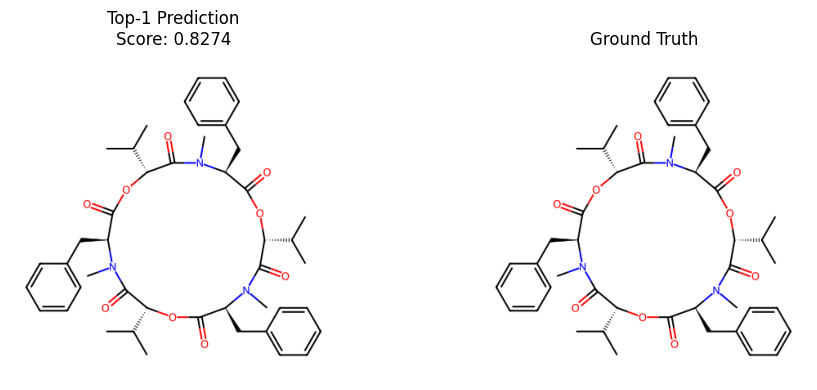

In [46]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display
import matplotlib.pyplot as plt

# Show top prediction vs true molecule
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Top prediction
top_smiles = predictions[0][0]
mol = Chem.MolFromSmiles(top_smiles)
if mol:
    img = Draw.MolToImage(mol, size=(400, 400))
    ax1.imshow(img)
    ax1.axis('off')
    ax1.set_title(f"Top-1 Prediction\nScore: {predictions[0][1]:.4f}")

# True molecule
mol_true = Chem.MolFromSmiles(true_smiles)
if mol_true:
    img_true = Draw.MolToImage(mol_true, size=(400, 400))
    ax2.imshow(img_true)
    ax2.axis('off')
    ax2.set_title("Ground Truth")

plt.tight_layout()
plt.show()